<a href="https://colab.research.google.com/github/ebi19912/AI/blob/main/MobileNetVGG16Autoencoder_DffrntLoss_ChestMultiLBL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d khanfashee/nih-chest-x-ray-14-224x224-resized
!unzip nih-chest-x-ray-14-224x224-resized.zip
!kaggle datasets download -d rouhalahebrahimi/autoencoder-xray-lungcancer
!unzip autoencoder-xray-lungcancer.zip

Streaming output truncated to the last 5000 lines.
  inflating: images-224/images-224/00028899_002.png  
  inflating: images-224/images-224/00028900_000.png  
  inflating: images-224/images-224/00028901_000.png  
  inflating: images-224/images-224/00028901_001.png  
  inflating: images-224/images-224/00028902_000.png  
  inflating: images-224/images-224/00028902_001.png  
  inflating: images-224/images-224/00028902_002.png  
  inflating: images-224/images-224/00028902_003.png  
  inflating: images-224/images-224/00028902_004.png  
  inflating: images-224/images-224/00028902_005.png  
  inflating: images-224/images-224/00028902_006.png  
  inflating: images-224/images-224/00028902_007.png  
  inflating: images-224/images-224/00028902_008.png  
  inflating: images-224/images-224/00028903_000.png  
  inflating: images-224/images-224/00028903_001.png  
  inflating: images-224/images-224/00028903_002.png  
  inflating: images-224/images-224/00028903_003.png  
  inflating: images-224/images-

In [ ]:

import os
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16 , MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Conv2D, BatchNormalization
from tensorflow.keras.layers import AvgPool2D, MaxPool2D, ReLU, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             matthews_corrcoef, average_precision_score, confusion_matrix,
                             roc_curve, roc_auc_score, precision_recall_curve)

from tensorflow.compat.v1.logging import INFO, set_verbosity
from tensorflow.python.framework.ops import disable_eager_execution
from matplotlib import rcParams
from keras.preprocessing import image

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping




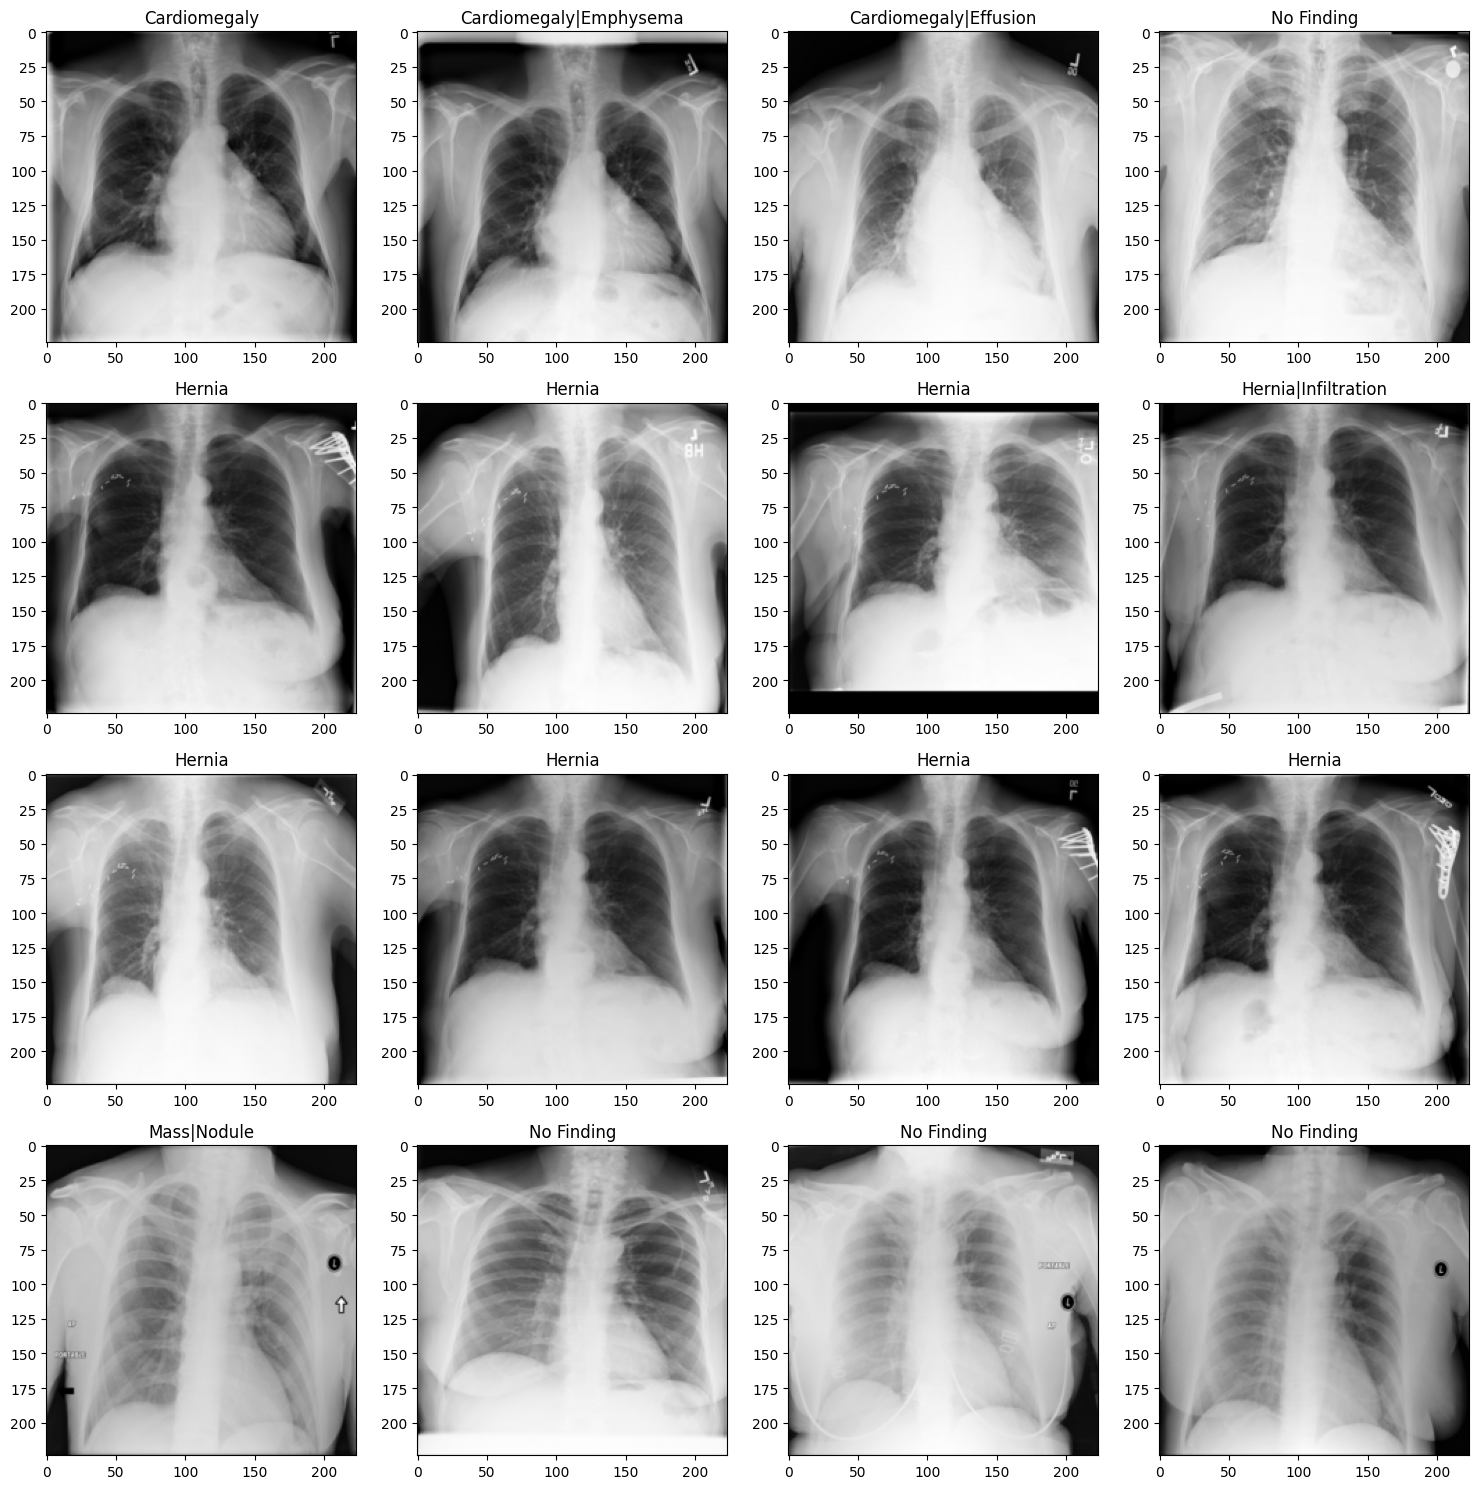

In [ ]:
dataframe = pd.read_csv("/content/Data_Entry_2017.csv")

#Enumerating all column names
columns = ["Image"]
for i in dataframe["Finding Labels"].values:
    for j in i.split("|"):
        if j not in columns:
            columns.append(j)
labels = columns.copy()
labels.remove("Image")

#Taking the first 77000 images from the master table as the train dataset
trainset = pd.DataFrame(columns = columns)
for i in range(77000):
    col = [0]*len(columns)
    col[0] = dataframe["Image Index"][i]
    count = 1
    for j in columns[1:]:
        if(j in dataframe["Finding Labels"][i]):
            col[count] = 1
        count+=1
    trainset.loc[len(trainset)] = col

#Taking the next 16500 images from the master table as the validation dataset
valset = pd.DataFrame(columns = columns)
for i in range(77000, 93500):
    col = [0]*len(columns)
    col[0] = dataframe["Image Index"][i]
    count = 1
    for j in columns[1:]:
        if(j in dataframe["Finding Labels"][i]):
            col[count] = 1
        count+=1
    valset.loc[len(valset)] = col

#Taking the next 16500 images from the master table as the test dataset
testset = pd.DataFrame(columns = columns)
for i in range(93500, 110000):
    col = [0]*len(columns)
    col[0] = dataframe["Image Index"][i]
    count = 1
    for j in columns[1:]:
        if(j in dataframe["Finding Labels"][i]):
            col[count] = 1
        count+=1
    testset.loc[len(testset)] = col

#Plotting first 16 images with their disease labels
img_dir = "/content/images-224/images-224"
plt.figure(figsize = (15,15))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(plt.imread(os.path.join(img_dir, trainset["Image"][i])), cmap = "gray")
    plt.title(dataframe[dataframe["Image Index"] == trainset["Image"][i]].values[0][1])
plt.tight_layout()

In [ ]:

# Define the desired labels
desired_labels = ["Mass", "Nodule", "No Finding", "Infiltration", "Emphysema", "Edema"]

# Function to filter the DataFrame
def filter_dataframe(df, desired_labels):
    # Create a boolean mask for rows with any of the desired labels
    mask = df[desired_labels].any(axis=1)

    # Filter the DataFrame based on the mask
    filtered_df = df[mask]

    # Select only desired columns
    filtered_df = filtered_df[["Image"] + desired_labels]

    return filtered_df

# Apply the filter to each DataFrame
trainset_filtered = filter_dataframe(trainset, desired_labels)
valset_filtered = filter_dataframe(valset, desired_labels)
testset_filtered = filter_dataframe(testset, desired_labels)



In [ ]:
def isOverlap(s1, s2):
    total = set(s1).intersection(set(s2))
    return [len(total), total]

def overlapcheck(trainset, valset, testset):
    patid_train = []
    patid_val = []
    patid_test = []
    for name in trainset['Image'].values:
        patid_train.append(int(name.split("_")[0]))

    for name in valset['Image'].values:
        patid_val.append(int(name.split("_")[0]))

    for name in testset['Image'].values:
        patid_test.append(int(name.split("_")[0]))
    trte = isOverlap(patid_train, patid_test)
    teva = isOverlap(patid_test, patid_val)
    trva = isOverlap(patid_train, patid_val)
    print("Patient Overlap - Train and Test: ", trte[0])
    print("Patient Overlap - Test and Validation: ", teva[0])
    print("Patient Overlap - Train and Validation: ", trva[0])
    return trte, teva, trva

#Checking for overlaps between trainset, testset and validation set
trte, teva, trva = overlapcheck(trainset, valset, testset)

#Removing overlapping patients
for i in trva[1]:
    for name in trainset['Image'].values:
        if(int(name.split("_")[0]) == i):
            trainset.drop(trainset.loc[trainset['Image'] == name].index, inplace=True)

#Checking for overlaps after removing common patients
trte, teva, trva = overlapcheck(trainset, valset, testset)

Patient Overlap - Train and Test:  0
Patient Overlap - Test and Validation:  1
Patient Overlap - Train and Validation:  1
Patient Overlap - Train and Test:  0
Patient Overlap - Test and Validation:  1
Patient Overlap - Train and Validation:  0


In [ ]:
def label_counts(df):
    label_counts = df[labels].sum().sort_values(ascending=False)
    return label_counts

print("Training Data Label Counts:")
print(label_counts(trainset))
print("\nValidation Data Label Counts:")
print(label_counts(valset))
print("\nTest Data Label Counts:")
print(label_counts(testset))

Training Data Label Counts:
No Finding            42478
Infiltration          12360
Effusion               8826
Atelectasis            7854
Nodule                 4060
Mass                   3970
Consolidation          3327
Pneumothorax           3282
Pleural_Thickening     2190
Cardiomegaly           1983
Emphysema              1759
Edema                  1667
Fibrosis               1365
Pneumonia               957
Hernia                  162
dtype: int64

Validation Data Label Counts:
No Finding            7824
Infiltration          3926
Effusion              2232
Atelectasis           1929
Nodule                1269
Mass                   939
Pneumothorax           867
Pleural_Thickening     671
Consolidation          669
Cardiomegaly           400
Edema                  353
Emphysema              278
Pneumonia              214
Fibrosis               198
Hernia                  36
dtype: int64

Test Data Label Counts:
No Finding            8978
Infiltration          3188
Effusion   

In [ ]:

print("Training Set Filtered:")
print(trainset_filtered)
print("\nValidation Set Filtered:")
print(valset_filtered)
print("\nTest Set Filtered:")
testset_filtered


Training Set Filtered:
                  Image  Mass  Nodule  No Finding  Infiltration  Emphysema  \
1      00000001_001.png     0       0           0             0          1   
3      00000002_000.png     0       0           1             0          0   
7      00000003_003.png     0       0           0             1          0   
12     00000004_000.png     1       1           0             0          0   
13     00000005_000.png     0       0           1             0          0   
...                 ...   ...     ...         ...           ...        ...   
76993  00018921_009.png     0       0           0             1          0   
76994  00018921_010.png     0       0           0             0          0   
76995  00018921_011.png     0       0           0             1          0   
76996  00018921_012.png     0       0           1             0          0   
76999  00018921_015.png     0       0           0             1          0   

       Edema  
1          0  
3         

,Image,Mass,Nodule,No Finding,Infiltration,Emphysema,Edema
0,00023428_001.png,0,0,1,0,0,0
1,00023428_002.png,0,0,1,0,0,0
2,00023429_000.png,0,0,1,0,0,0
4,00023431_000.png,0,0,1,0,0,0
5,00023432_000.png,0,0,1,0,0,0
...,...,...,...,...,...,...,...
16495,00029933_001.png,0,0,1,0,0,0
16496,00029933_002.png,0,0,1,0,0,0
16497,00029934_000.png,0,0,1,0,0,0
16498,00029935_000.png,0,0,1,0,0,0


Maximum Pixel Value:  0.96862745
Minimum Pixel Value:  0.0
Image dimension: 224 x 224 
Mean - Pixel Value:  0.6264852
Std Deviation Pixel Value:  0.24666156


<Axes: xlabel='Pixel Values', ylabel='Count'>

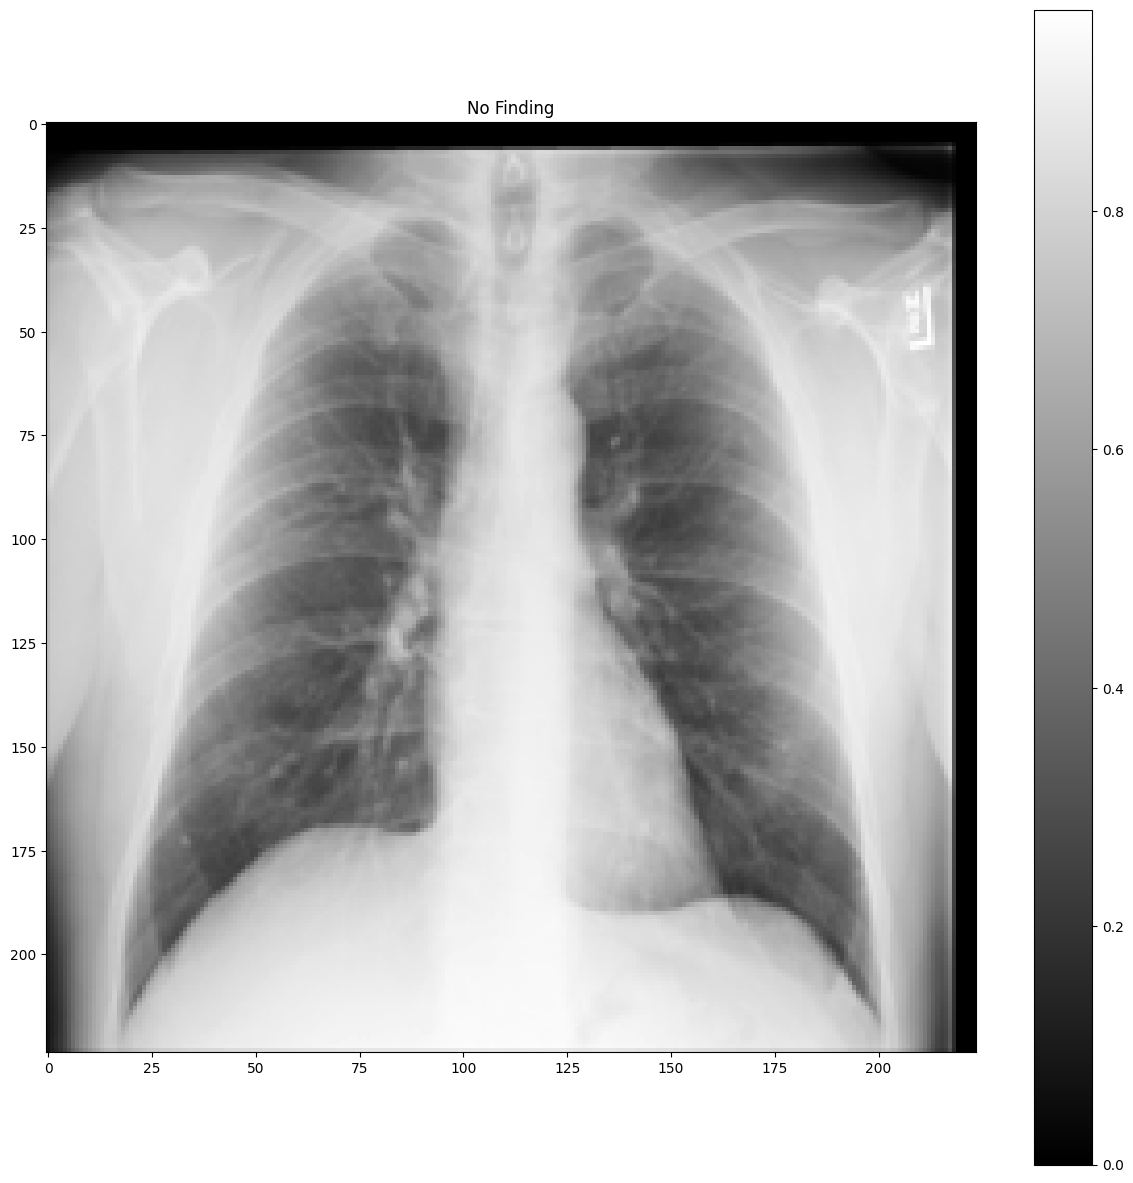

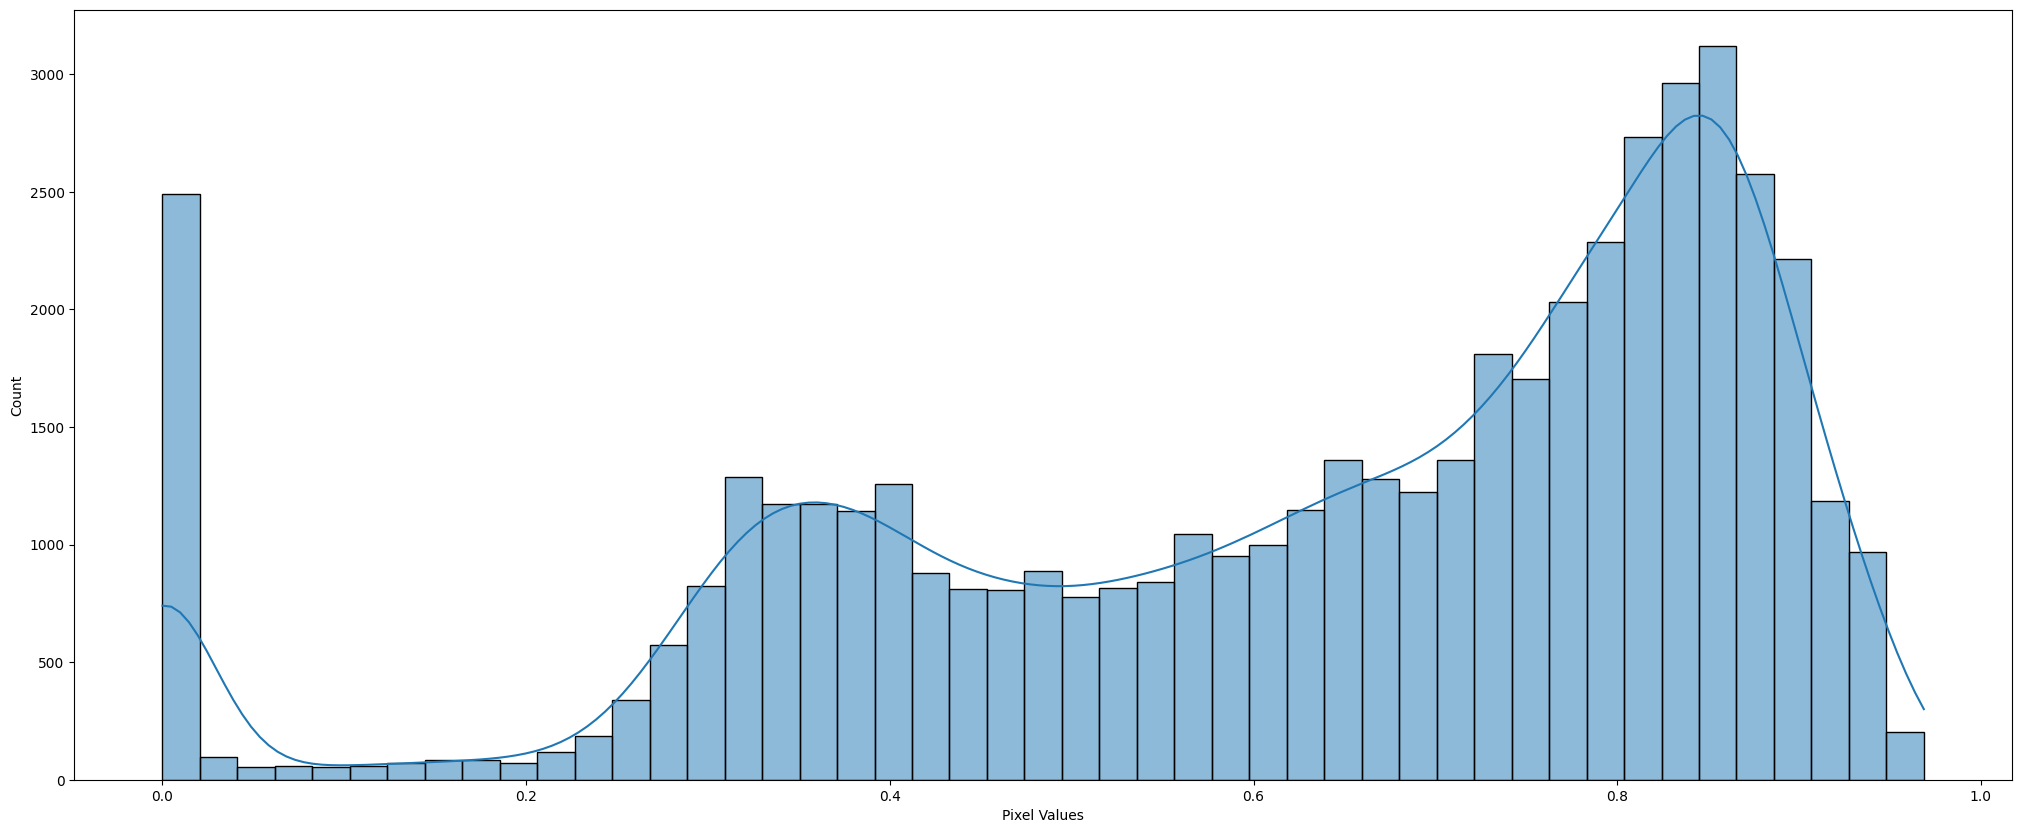

In [ ]:
num = np.random.randint(trainset_filtered.shape[0])
sample = plt.imread(os.path.join(img_dir,trainset_filtered.iloc[[num]]["Image"].values[0]))
plt.figure(figsize=(15, 15))
plt.title(dataframe[dataframe["Image Index"] == trainset_filtered.iloc[[num]]["Image"].values[0]].values[0][1])
plt.imshow(sample, cmap = 'gray')
plt.colorbar()
trainset_filtered.iloc[[num]]

print("Maximum Pixel Value: ", sample.max())
print("Minimum Pixel Value: ", sample.min())
print(f"Image dimension: {sample.shape[0]} x {sample.shape[1]} ")

fig, ax = plt.subplots(figsize=(25, 10))
plt.xlabel("Pixel Values")
print("Mean - Pixel Value: ", sample.mean())
print("Std Deviation Pixel Value: ", sample.std())
sns.histplot(sample.ravel(), ax = ax, kde = True)

In [ ]:
#Correct the labels variable
labels = desired_labels
labels

['Mass', 'Nodule', 'No Finding', 'Infiltration', 'Emphysema', 'Edema']

Found 62928 validated image filenames.
Found 62928 validated image filenames.
Found 13539 validated image filenames.
Found 13767 validated image filenames.


Mean of Pixel Values - Standardized:  3.2194617e-07
Standard Deviation of Pixel Values - Standardized:  1.0
Mean of Pixel Values - Sample:  0.6264852
Standard Deviation of Pixel Values - Sample:  0.24666156


<Axes: xlabel='Pixel Values', ylabel='Count'>

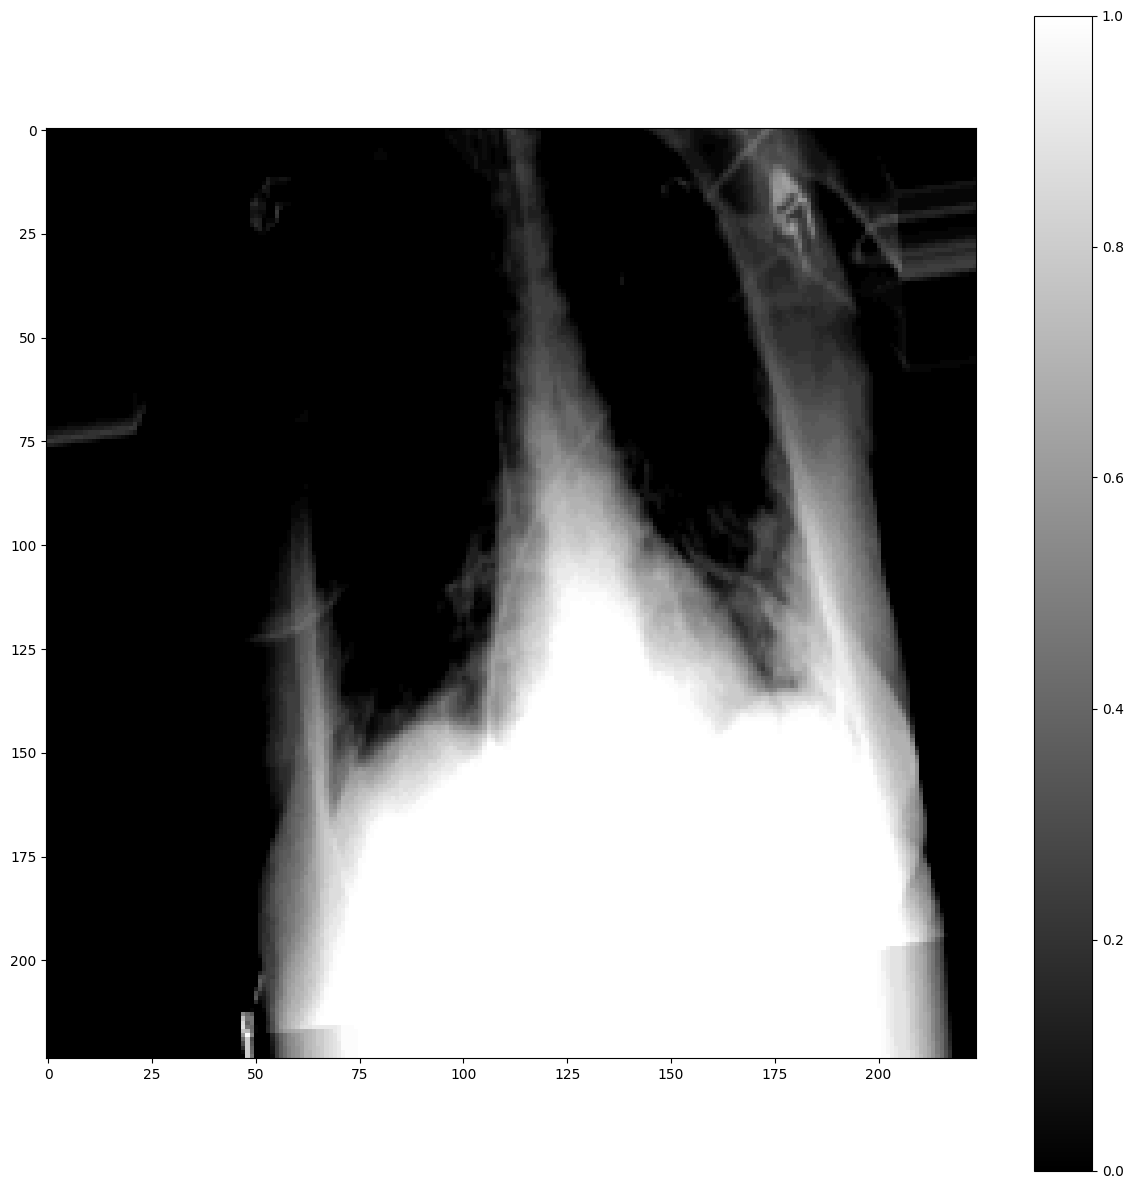

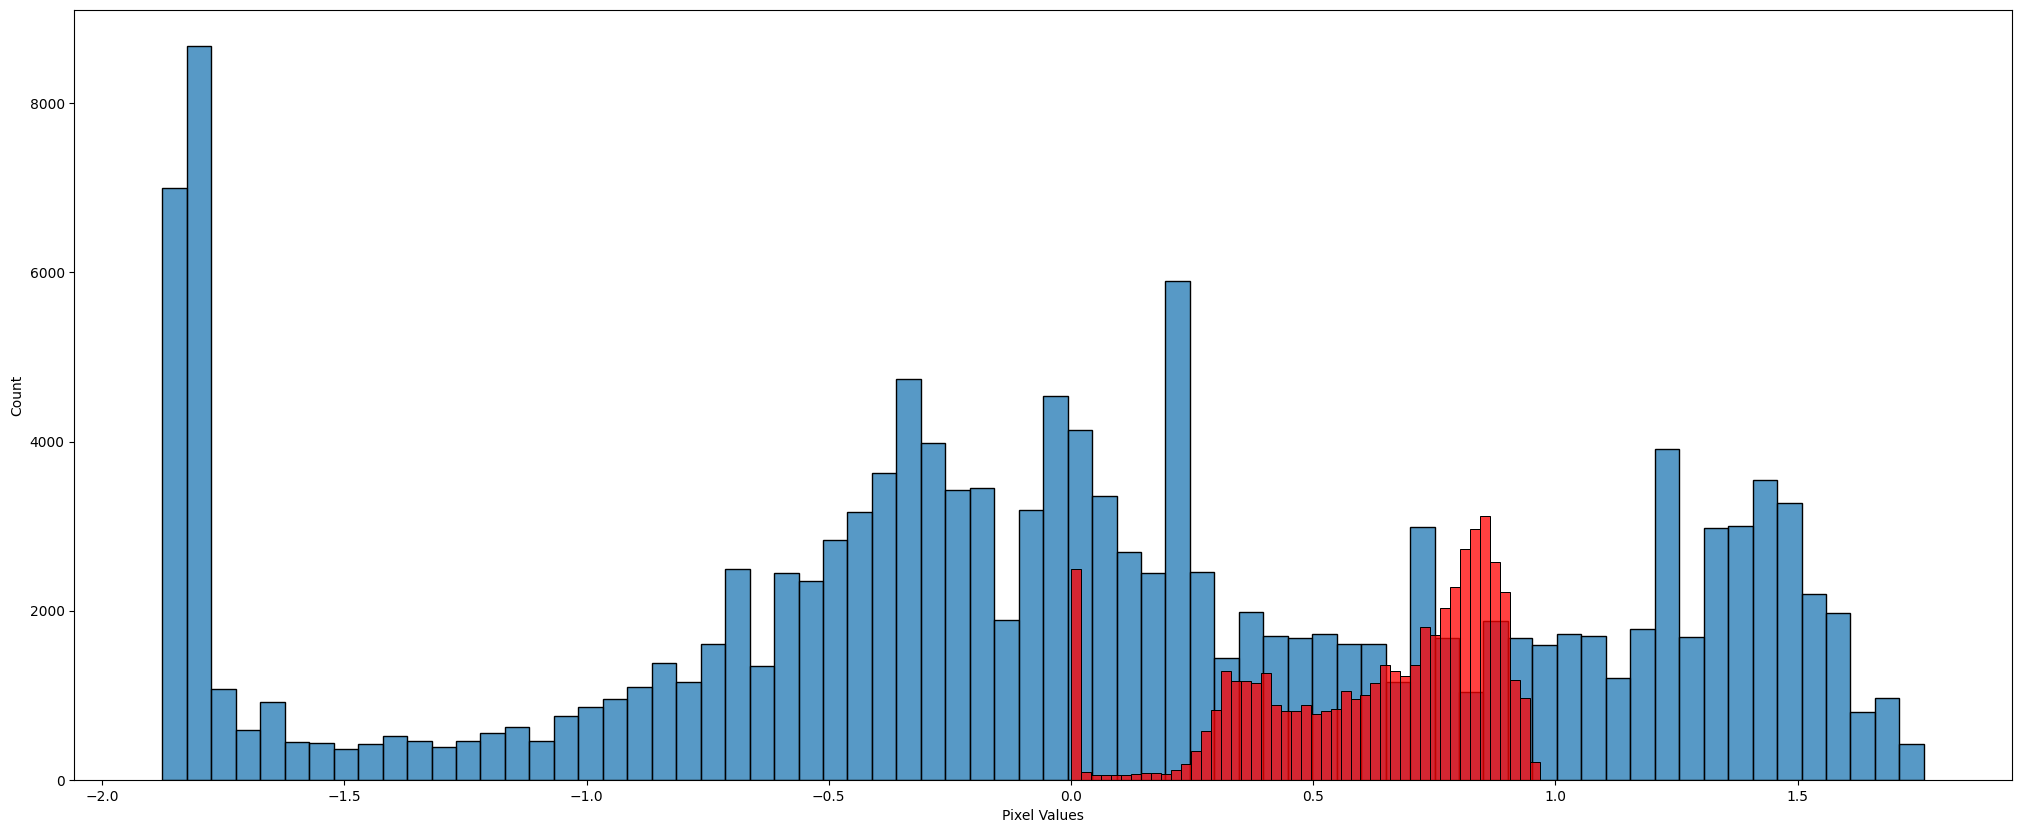

In [ ]:
def adjust_contrast_and_saturation(image):
  # Generate a random contrast factor between 0.4 and 0.9
  contrast_factor = tf.random.uniform([], 0.4, 0.9)
  image = tf.image.adjust_contrast(image, contrast_factor)

  # Generate a random saturation factor between 0.4 and 0.9
  saturation_factor = tf.random.uniform([], 0.4, 0.9)
  image = tf.image.adjust_saturation(image, saturation_factor)

  return image

traingen = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True,
    brightness_range=[0.3, 1.2],
    zoom_range=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    preprocessing_function=adjust_contrast_and_saturation
)
img_dir = "/content/images-224/images-224"
bach=64
traingenerator = traingen.flow_from_dataframe(
        dataframe=trainset_filtered,
        directory=img_dir,
        x_col="Image",
        y_col= labels,
        class_mode="raw",
        batch_size= bach,
        shuffle=False,
        target_size=(224,224)
)
#Standardizing featurewise as we don't process images as groups rather one-by-one
imagegen = ImageDataGenerator().flow_from_dataframe(dataframe = trainset_filtered,
                                                    directory = img_dir,
                                                    x_col = "Image",
                                                    y_col = labels, class_mode = "raw",
                                                    batch_size= bach,
                                                    shuffle=False,
                                                    target_size=(224,224))
train_sample = next(imagegen)[0]
imagegen = ImageDataGenerator(featurewise_center=True, featurewise_std_normalization= True)
imagegen.fit(train_sample)
valgenerator = imagegen.flow_from_dataframe(dataframe = valset_filtered,
                                            directory = img_dir,
                                            x_col = "Image",
                                            y_col = labels,
                                            class_mode = "raw",
                                            batch_size= bach,
                                            shuffle=False,
                                            target_size=(224,224))
testgenerator = imagegen.flow_from_dataframe(dataframe = testset_filtered,
                                             directory = img_dir,
                                             x_col = "Image",
                                             y_col = labels,
                                             class_mode = "raw",
                                             batch_size= bach,
                                             shuffle=False,
                                             target_size=(224,224))


#Taking a random sample standardized image
num = np.random.randint(len(traingenerator))

item, value = traingenerator.__getitem__(num)
plt.figure(figsize=(15, 15))
plt.imshow(item[0], cmap = 'gray')
plt.colorbar()

#Plotting the histogram of original and standardized pixel intensities
fig, ax = plt.subplots(figsize=(25, 10))
plt.xlabel("Pixel Values")
print("Mean of Pixel Values - Standardized: ", item[0].mean())
print("Standard Deviation of Pixel Values - Standardized: ", item[0].std())
print("Mean of Pixel Values - Sample: ", sample.mean())
print("Standard Deviation of Pixel Values - Sample: ", sample.std())
sns.histplot(item[0].ravel(), ax = ax, kde = False)
sns.histplot(sample.ravel(), ax = ax, kde = False, color = "red")

<Figure size 2000x1500 with 0 Axes>

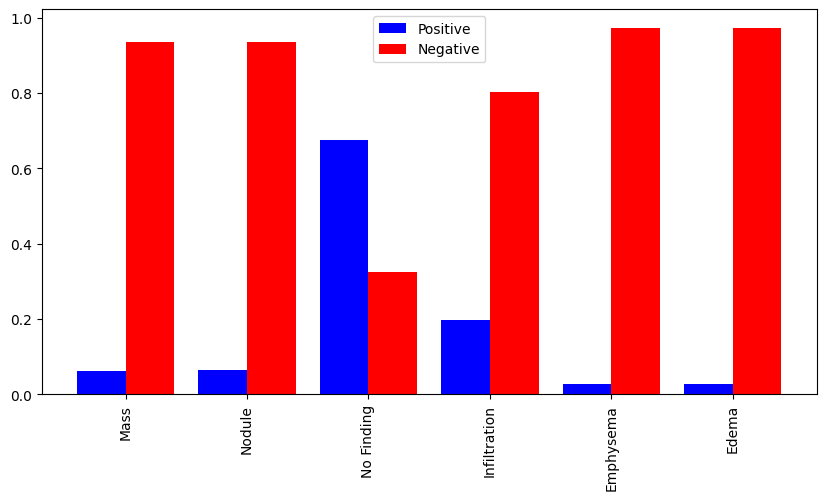

<Figure size 2000x1500 with 0 Axes>

In [ ]:
# Calculate positive and negative frequencies for each label
positive_freqs = trainset_filtered[labels].sum().values / trainset_filtered.shape[0]  # Assuming labels are 1 for positive, 0 for negative
negative_freqs = 1 - positive_freqs

data = {
    'Class': labels,
    'Positive': positive_freqs,
    'Negative': negative_freqs
}

X_axis = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(X_axis-0.2, data['Positive'], width=0.4, color='b', label = "Positive")
ax.bar(X_axis+0.2, data['Negative'], width=0.4, color='r', label = 'Negative')
plt.xticks(X_axis, labels, rotation = 90)
plt.legend()
plt.figure(figsize=(20,15))

In [ ]:
save_dir = '/content/'

In [ ]:

def create_model():

    input_tensor = Input(shape=(224, 224, 3))
    encoder_model = load_model('/content/encoder_model.h5', compile=False)
    for layer in encoder_model.layers:
        layer.trainable = False
    print("Custom encoder model created and frozen.")

    mobilenet_base = MobileNet(
        weights='imagenet',
        include_top=False,
        input_tensor=input_tensor
    )
    for layer in mobilenet_base.layers[:-5]:
        layer.trainable = False
    x_mobilenet = mobilenet_base.output
    x_mobilenet = GlobalAveragePooling2D()(x_mobilenet)
    x_mobilenet = Dense(256, activation='relu')(x_mobilenet)

    vgg16_base = VGG16(
        weights='imagenet',
        include_top=False,
        input_tensor=input_tensor
    )
    for layer in vgg16_base.layers[:-5]:
        layer.trainable = False
    x_vgg16 = vgg16_base.output
    x_vgg16 = GlobalAveragePooling2D()(x_vgg16)
    x_vgg16 = Dense(256, activation='relu')(x_vgg16)

    mono_channel_input = Conv2D(1, (1, 1), activation='linear', name='rgb_to_grayscale')(input_tensor)
    encoded_features = encoder_model(mono_channel_input)
    x_autoencoder = GlobalAveragePooling2D()(encoded_features)
    x_autoencoder = Dense(256, activation='relu')(x_autoencoder)

    merged = concatenate([x_mobilenet, x_vgg16, x_autoencoder])

    output = Dense(len(labels), activation='sigmoid')(merged)

    model = Model(inputs=input_tensor, outputs=output)
    return model

model = create_model()
model.summary()

Custom encoder model created and frozen.


/tmp/ipython-input-13-72687218.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNet(


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1           │ (None, 112, 112,  │        288 │ conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1_bn        │ (None, 112, 112,  │        128 │ conv_dw_1[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1_relu      │ (None, 112, 112,  │          0 │ conv_dw_1_bn[0][… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1 (Conv2D)  │ (None, 112, 112,  │      2,048 │ conv_dw_1_relu[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1_bn        │ (None, 112, 112,  │        256 │ conv_pw_1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1_relu      │ (None, 112, 112,  │          0 │ conv_pw_1_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pad_2          │ (None, 113, 113,  │          0 │ conv_pw_1_relu[0… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2           │ (None, 56, 56,    │        576 │ conv_pad_2[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2_bn        │ (None, 56, 56,    │        256 │ conv_dw_2[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2_relu      │ (None, 56, 56,    │          0 │ conv_dw_2_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2 (Conv2D)  │ (None, 56, 56,    │      8,192 │ conv_dw_2_relu[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2_bn        │ (None, 56, 56,    │        512 │ conv_pw_2[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2_relu      │ (None, 56, 56,    │          0 │ conv_pw_2_bn[0][

 Total params: 18,467,594 (70.45 MB)

 Trainable params: 8,563,466 (32.67 MB)

 Non-trainable params: 9,904,128 (37.78 MB)

In [ ]:

def weighted_cross_entropy(y_true, y_pred):
# Calculate positive and negative weights based on class frequencies in your dataset.
  positive_weights = tf.constant(positive_freqs, dtype=tf.float32)
  negative_weights = tf.constant(negative_freqs, dtype=tf.float32)
  loss = -(y_true * tf.math.log(y_pred + 1e-7) * positive_weights + (1 - y_true) * tf.math.log(1 - y_pred + 1e-7) * negative_weights)
  return tf.reduce_mean(loss)
def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """
    Calculates Focal Loss. This function down-weights the loss assigned to
    well-classified examples, focusing on hard, misclassified examples.

    Args:
        y_true: Ground truth values (0 or 1).
        y_pred: Predicted probabilities.
        alpha: A balancing factor for the classes, typically set to the inverse
               class frequency.
        gamma: The focusing parameter that adjusts the rate at which easy examples
               are down-weighted.

    Returns:
        The mean focal loss.
    """
    # Ensure y_pred is clipped to avoid log(0)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

    # Calculate cross-entropy
    cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)

    # Calculate p_t
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)

    # Calculate the modulating factor
    modulating_factor = tf.pow(1.0 - p_t, gamma)

    # Calculate the alpha weight
    alpha_weight = y_true * alpha + (1 - y_true) * (1 - alpha)

    # Combine for the final focal loss
    focal_loss = alpha_weight * modulating_factor * cross_entropy

    return tf.reduce_mean(focal_loss)

def dice_loss(y_true, y_pred, epsilon=1e-7):
    """
    Calculates Dice Loss. Excellent for imbalanced problems as it directly
    optimizes for the F1-score (overlap between prediction and ground truth).

    Args:
        y_true: Ground truth values (0 or 1).
        y_pred: Predicted probabilities.
        epsilon: A small constant to avoid division by zero.

    Returns:
        The dice loss.
    """
    # Flatten the tensors to calculate intersection and union
    y_true_flat = tf.keras.backend.flatten(y_true)
    y_pred_flat = tf.keras.backend.flatten(y_pred)

    # Calculate the intersection (true positives)
    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)

    # Calculate the union
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)

    # Calculate the dice coefficient and dice loss
    dice_coefficient = (2. * intersection + epsilon) / (union + epsilon)

    return 1 - dice_coefficient

def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, epsilon=1e-7):
    """
    Calculates Tversky Loss. A generalization of Dice Loss that allows for
    separate weighting of false positives (FP) and false negatives (FN).

    Args:
        y_true: Ground truth values (0 or 1).
        y_pred: Predicted probabilities.
        alpha: Controls the penalty for false negatives (FN).
        beta: Controls the penalty for false positives (FP).
        epsilon: A small constant to avoid division by zero.

    Returns:
        The tversky loss.
    """
    y_true = tf.cast(y_true, y_pred.dtype)

    # Calculate True Positives, False Positives, and False Negatives
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    # Calculate the Tversky Index and loss
    tversky_index = (tp + epsilon) / (tp + alpha * fn + beta * fp + epsilon)

    return 1 - tversky_index

def asymmetric_focusing_cross_entropy(y_true, y_pred, alpha=0.25, gamma_fn=3.0, gamma_fp=1.0):
    """
    Calculates Asymmetric Focusing Cross-Entropy (AFCE). This novel loss
    combines ideas from Focal and Tversky loss to apply different focusing
    parameters to false negatives and false positives.

    Args:
        y_true: Ground truth values (0 or 1).
        y_pred: Predicted probabilities.
        alpha: The class balance weight.
        gamma_fn: The focusing parameter for false negatives (positive class).
        gamma_fp: The focusing parameter for false positives (negative class).

    Returns:
        The mean AFCE loss.
    """
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

    # Loss for the positive class (focusing on false negatives)
    loss_pos = -alpha * tf.pow(1. - y_pred, gamma_fn) * tf.math.log(y_pred)

    # Loss for the negative class (focusing on false positives)
    loss_neg = -(1 - alpha) * tf.pow(y_pred, gamma_fp) * tf.math.log(1. - y_pred)

    # Combine the losses based on the ground truth
    final_loss = y_true * loss_pos + (1. - y_true) * loss_neg

    return tf.reduce_mean(final_loss)


**weighted_cross_entropy**

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6537 - loss: 0.1233
Epoch 1: val_accuracy improved from -inf to 0.57877, saving model to MobileNet+VGG16+Autoencoder_chest_weighted_cross_entropy.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1138s 1s/step - accuracy: 0.6537 - loss: 0.1232 - val_accuracy: 0.5788 - val_loss: 0.0933
Epoch 2/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6739 - loss: 0.0749
Epoch 2: val_accuracy improved from 0.57877 to 0.58032, saving model to MobileNet+VGG16+Autoencoder_chest_weighted_cross_entropy.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1080s 1s/step - accuracy: 0.6739 - loss: 0.0749 - val_accuracy: 0.5803 - val_loss: 0.0929
Epoch 3/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6792 - loss: 0.0731
Epoch 3: val_accuracy did not improve from 0.58032
984/984 ━━━━━━━━━━━━━━━━━━━━ 1080s 1s/step - accuracy: 0.6792 - loss: 0.0731 - val_accuracy: 0.5780 - val_loss: 0.0947
Epoch 4/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Infiltration: 0.09980000000000001
Confusion Matrix for Infiltration (Threshold: 0.09980000000000001):
[[8312 2267]
 [1691 1497]]
Specificity for Infiltration: 0.7857075337933642
Best threshold for Emphysema: 0.008199999999999999
Confusion Matrix for Emphysema (Threshold: 0.008199999999999999):
[[13361     0]
 [  406     0]]
Specificity for Emphysema: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Edema: 0.0094
Confusion Matrix for Edema (Threshold: 0.0094):
[[13494    13]
 [  257     3]]
Specificity for Edema: 0.9990375360923965
          Label  Best Threshold  Weighted Precision  Weighted Recall  \
0          Mass          0.0122            0.914297         0.944142   
1        Nodule          0.0147            0.889189         0.932956   
2    No Finding          0.0001            0.425286         0.652139   
3  Infiltration          0.0998            0.730627         0.712501   
4     Emphysema          0.0082            0.941888         0.970509   
5         Edema          0.0094            0.966319         0.980388   

   Weighted F1-Score  Accuracy       MCC    AUC-PR  
0           0.922027  0.944142  0.091422  0.128392  
1           0.904451  0.932956  0.038851  0.096984  
2           0.514830  0.652139  0.000000  0.800732  
3           0.720388  0.712501  0.241607  0.387588  
4           0.955984  0.970509  0.000000  0.078141  
5           0.971807  0

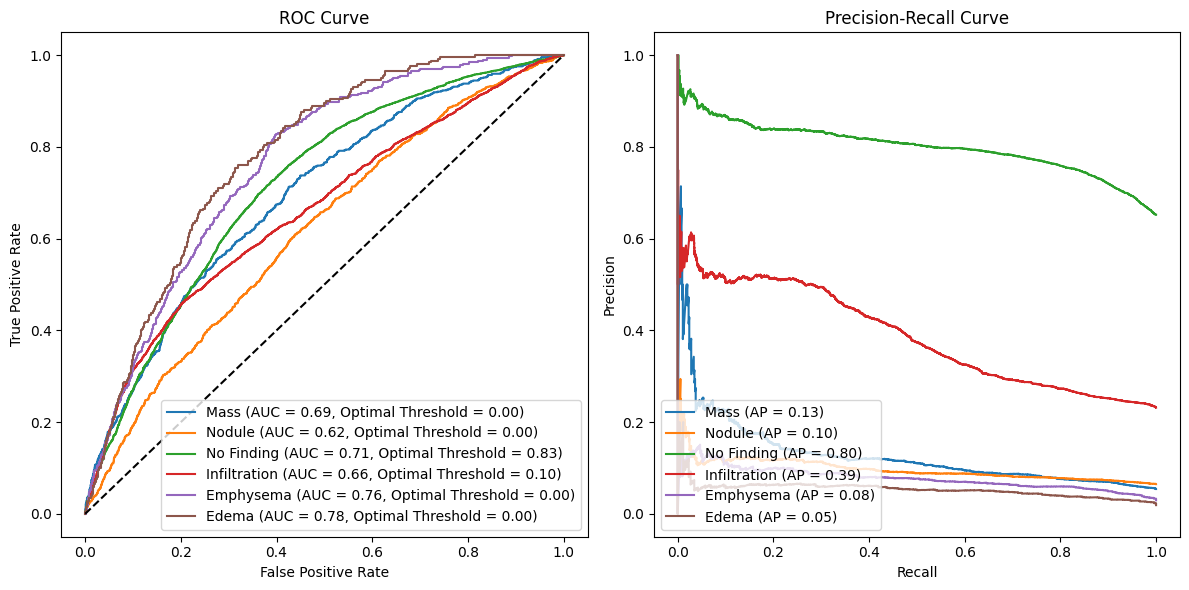

Best threshold for Mass: 0.0048000000000000004
Confusion Matrix for Mass (Threshold: 0.0048000000000000004):
[[10619  2404]
 [  419   325]]
Specificity for Mass: 0.8154035168547954
Best threshold for Nodule: 0.0055000000000000005
Confusion Matrix for Nodule (Threshold: 0.0055000000000000005):
[[10793  2083]
 [  624   267]]
Specificity for Nodule: 0.8382261571916745
Best threshold for No Finding: 0.0001
Confusion Matrix for No Finding (Threshold: 0.0001):
[[   0 4789]
 [   0 8978]]
Specificity for No Finding: 0.0
Best threshold for Infiltration: 0.099
Confusion Matrix for Infiltration (Threshold: 0.099):
[[8296 2283]
 [1686 1502]]
Specificity for Infiltration: 0.7841951035069478
Best threshold for Emphysema: 0.0016
Confusion Matrix for Emphysema (Threshold: 0.0016):
[[11913  1448]
 [  265   141]]
Specificity for Emphysema: 0.8916248783773669
Best threshold for Edema: 0.0015
Confusion Matrix for Edema (Threshold: 0.0015):
[[11810  1697]
 [  151   109]]
Specificity for Edema: 0.8743614422

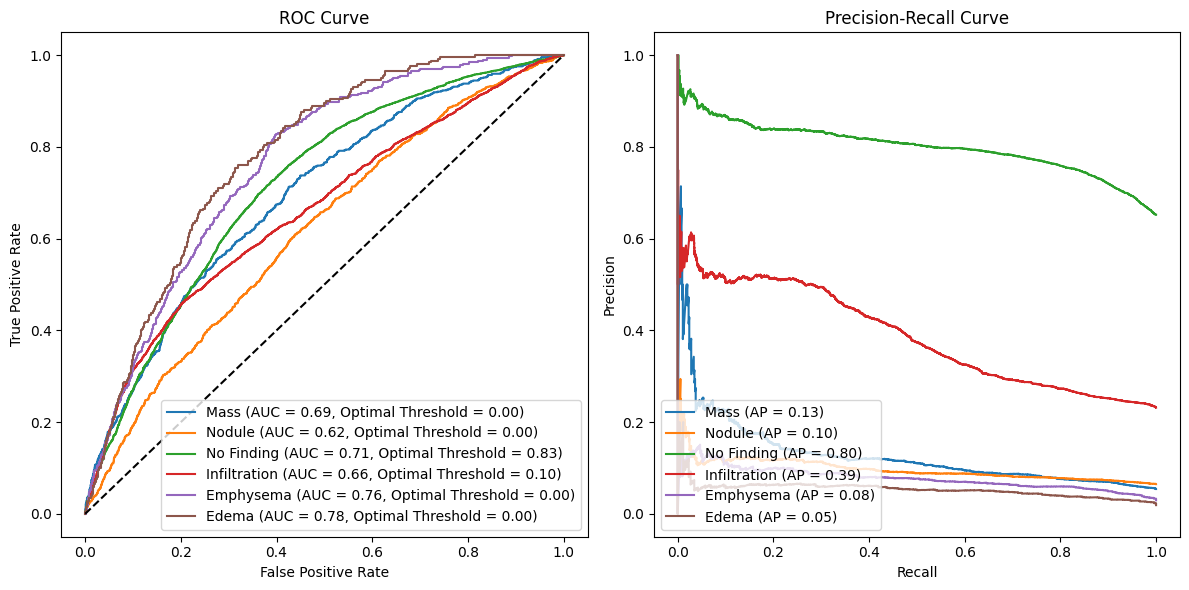

In [ ]:
# Function to train the model and save it
def train_and_save_model(model_name):
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=1e-5), loss=weighted_cross_entropy, metrics=['accuracy'])

    # Define callbacks
    checkpoint = ModelCheckpoint(f'{model_name}.keras',
                                 monitor='val_accuracy',
                                 verbose=1,
                                 save_best_only=True,
                                 mode='max')
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    # Train the model
    history = model.fit(
        traingenerator,
        epochs=100,
        validation_data=valgenerator,
        callbacks=[checkpoint, early_stopping]
    )

    return history

# Train the model and save it
history = train_and_save_model('MobileNet+VGG16+Autoencoder_chest_weighted_cross_entropy')
###################################################################################################################

weighted_precision_list = []
weighted_recall_list = []
weighted_f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

predicted_vals = model.predict(testgenerator)
all_gt = np.array(testgenerator.labels)
all_pred_probs = predicted_vals

for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred_probs = all_pred_probs[:, i]

        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred, average="weighted")
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        pred = (pred_probs > best_thresh).astype(int)

        weighted_precision = precision_score(gt, pred, average="weighted")
        weighted_recall = recall_score(gt, pred, average="weighted")
        weighted_f1 = f1_score(gt, pred, average="weighted")
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        weighted_precision_list.append(weighted_precision)
        weighted_recall_list.append(weighted_recall)
        weighted_f1_list.append(weighted_f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass

metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Weighted Precision': weighted_precision_list,
    'Weighted Recall': weighted_recall_list,
    'Weighted F1-Score': weighted_f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

print("\nOverall Weighted Metrics:")
print(f"Mean Weighted Precision: {np.mean(weighted_precision_list):.4f}")
print(f"Mean Weighted Recall: {np.mean(weighted_recall_list):.4f}")
print(f"Mean Weighted F1-Score: {np.mean(weighted_f1_list):.4f}")
print(f"Mean Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Mean MCC: {np.mean(mcc_list):.4f}")
print(f"Mean AUC-PR: {np.mean(auc_pr_list):.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        youden_j = tpr - fpr
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()
##############################################################################################
# Initialize lists to store evaluation metrics for each label
precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

# Iterate through labels and calculate metrics
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred_probs = predicted_vals[:, i]

        # Find optimal threshold based on F1-score
        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        # Use the best threshold for evaluation
        pred = (pred_probs > best_thresh).astype(int)

        precision = precision_score(gt, pred)
        recall = recall_score(gt, pred)
        f1 = f1_score(gt, pred)
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        # Calculate Confusion Matrix
        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)
        # Calculate Specificity
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)
        print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass


# Store the metrics in a DataFrame for better presentation
metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-Score': f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

# Plot ROC and PR curves for each label in one plot
plt.figure(figsize=(12, 6))

# ROC curve
plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        # Calculate Youden's J for each threshold
        youden_j = tpr - fpr

        # Find the optimal threshold based on Youden's J
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# PR curve
plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

**focal_loss**

Epoch 1/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6663 - loss: 0.0331
Epoch 1: val_accuracy improved from -inf to 0.59295, saving model to MobileNet+VGG16+Autoencoder_chest_focal_loss.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1096s 1s/step - accuracy: 0.6664 - loss: 0.0331 - val_accuracy: 0.5930 - val_loss: 0.0348
Epoch 2/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6766 - loss: 0.0290
Epoch 2: val_accuracy improved from 0.59295 to 0.59916, saving model to MobileNet+VGG16+Autoencoder_chest_focal_loss.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1080s 1s/step - accuracy: 0.6766 - loss: 0.0290 - val_accuracy: 0.5992 - val_loss: 0.0352
Epoch 3/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6760 - loss: 0.0289
Epoch 3: val_accuracy did not improve from 0.59916
984/984 ━━━━━━━━━━━━━━━━━━━━ 1087s 1s/step - accuracy: 0.6760 - loss: 0.0289 - val_accuracy: 0.5954 - val_loss: 0.0333
Epoch 4/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6779 - loss: 0.0284
Epoch

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Infiltration: 0.0995
Confusion Matrix for Infiltration (Threshold: 0.0995):
[[   13 10566]
 [    0  3188]]
Specificity for Infiltration: 0.0012288496077133945
Best threshold for Emphysema: 0.0999
Confusion Matrix for Emphysema (Threshold: 0.0999):
[[8247 5114]
 [  69  337]]
Specificity for Emphysema: 0.6172442182471372
Best threshold for Edema: 0.0999
Confusion Matrix for Edema (Threshold: 0.0999):
[[8993 4514]
 [  22  238]]
Specificity for Edema: 0.6658029170059969
          Label  Best Threshold  Weighted Precision  Weighted Recall  \
0          Mass          0.0999            0.938045         0.144984   
1        Nodule          0.0999            0.917122         0.113605   
2    No Finding          0.0001            0.425286         0.652139   
3  Infiltration          0.0995            0.822106         0.232513   
4     Emphysema          0.0999            0.964280         0.623520   
5         Edema          0.0999            0.979666         0.670516   

   We

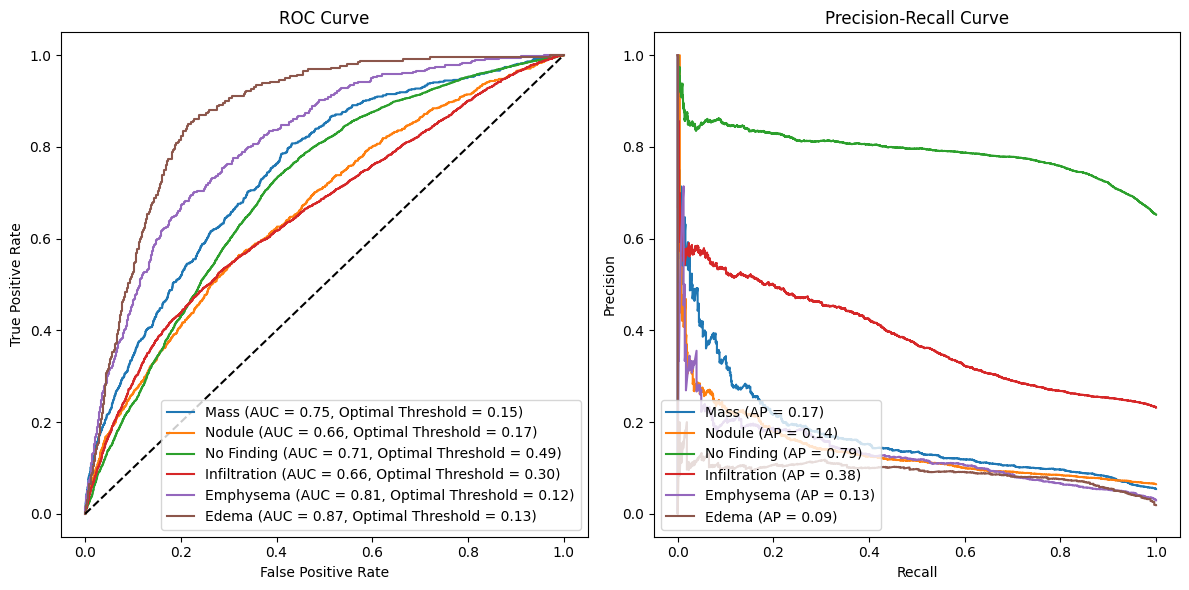

Best threshold for Mass: 0.09980000000000001
Confusion Matrix for Mass (Threshold: 0.09980000000000001):
[[ 1257 11766]
 [   14   730]]
Specificity for Mass: 0.09652153881594103
Best threshold for Nodule: 0.09960000000000001
Confusion Matrix for Nodule (Threshold: 0.09960000000000001):
[[  677 12199]
 [   15   876]]
Specificity for Nodule: 0.052578440509474994
Best threshold for No Finding: 0.0001
Confusion Matrix for No Finding (Threshold: 0.0001):
[[   0 4789]
 [   0 8978]]
Specificity for No Finding: 0.0
Best threshold for Infiltration: 0.0995
Confusion Matrix for Infiltration (Threshold: 0.0995):
[[   13 10566]
 [    0  3188]]
Specificity for Infiltration: 0.0012288496077133945
Best threshold for Emphysema: 0.09970000000000001
Confusion Matrix for Emphysema (Threshold: 0.09970000000000001):
[[8227 5134]
 [  67  339]]
Specificity for Emphysema: 0.6157473243020732
Best threshold for Edema: 0.0995
Confusion Matrix for Edema (Threshold: 0.0995):
[[8965 4542]
 [  20  240]]
Specificity f

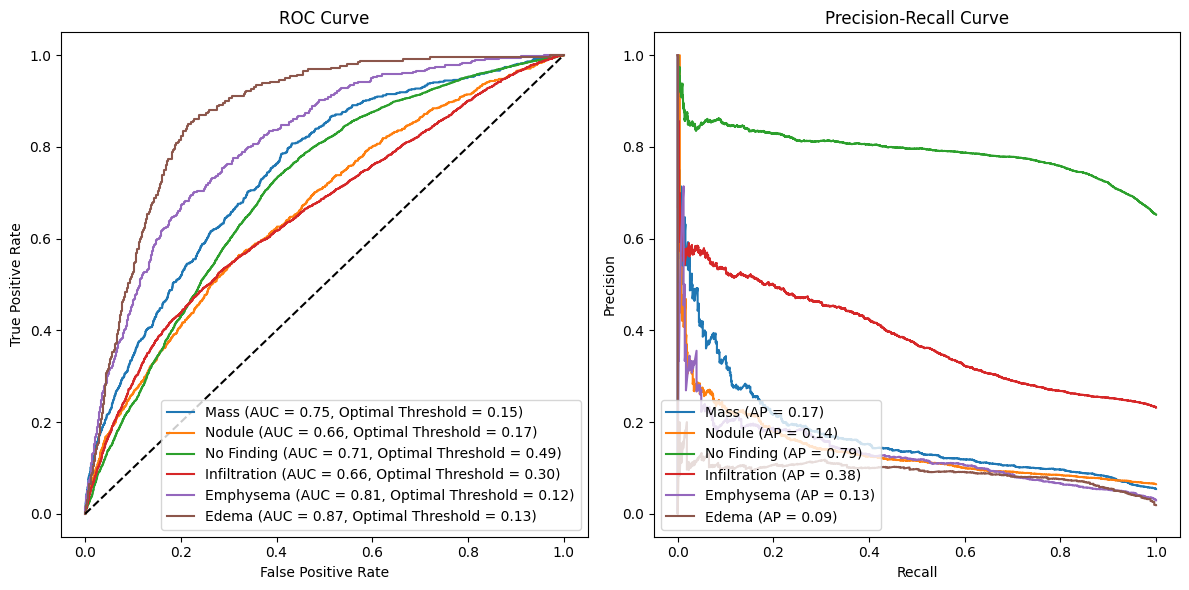

In [ ]:

# Function to train the model and save it
def train_and_save_model(model_name):
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=1e-5), loss=focal_loss, metrics=['accuracy'])

    # Define callbacks
    checkpoint = ModelCheckpoint(f'{model_name}.keras',
                                 monitor='val_accuracy',
                                 verbose=1,
                                 save_best_only=True,
                                 mode='max')
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    # Train the model
    history = model.fit(
        traingenerator,
        epochs=100,
        validation_data=valgenerator,
        callbacks=[checkpoint, early_stopping]
    )

    return history

# Train the model and save it
history = train_and_save_model('MobileNet+VGG16+Autoencoder_chest_focal_loss')
###################################################################################################################

weighted_precision_list = []
weighted_recall_list = []
weighted_f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

predicted_vals = model.predict(testgenerator)
all_gt = np.array(testgenerator.labels)
all_pred_probs = predicted_vals

for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred_probs = all_pred_probs[:, i]

        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred, average="weighted")
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        pred = (pred_probs > best_thresh).astype(int)

        weighted_precision = precision_score(gt, pred, average="weighted")
        weighted_recall = recall_score(gt, pred, average="weighted")
        weighted_f1 = f1_score(gt, pred, average="weighted")
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        weighted_precision_list.append(weighted_precision)
        weighted_recall_list.append(weighted_recall)
        weighted_f1_list.append(weighted_f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass

metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Weighted Precision': weighted_precision_list,
    'Weighted Recall': weighted_recall_list,
    'Weighted F1-Score': weighted_f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

print("\nOverall Weighted Metrics:")
print(f"Mean Weighted Precision: {np.mean(weighted_precision_list):.4f}")
print(f"Mean Weighted Recall: {np.mean(weighted_recall_list):.4f}")
print(f"Mean Weighted F1-Score: {np.mean(weighted_f1_list):.4f}")
print(f"Mean Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Mean MCC: {np.mean(mcc_list):.4f}")
print(f"Mean AUC-PR: {np.mean(auc_pr_list):.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        youden_j = tpr - fpr
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()
##############################################################################################
# Initialize lists to store evaluation metrics for each label
precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

# Iterate through labels and calculate metrics
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred_probs = predicted_vals[:, i]

        # Find optimal threshold based on F1-score
        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        # Use the best threshold for evaluation
        pred = (pred_probs > best_thresh).astype(int)

        precision = precision_score(gt, pred)
        recall = recall_score(gt, pred)
        f1 = f1_score(gt, pred)
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        # Calculate Confusion Matrix
        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)
        # Calculate Specificity
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)
        print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass


# Store the metrics in a DataFrame for better presentation
metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-Score': f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

# Plot ROC and PR curves for each label in one plot
plt.figure(figsize=(12, 6))

# ROC curve
plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        # Calculate Youden's J for each threshold
        youden_j = tpr - fpr

        # Find the optimal threshold based on Youden's J
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# PR curve
plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

**dice_loss**

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0574 - loss: 0.6282
Epoch 1: val_accuracy improved from -inf to 0.11441, saving model to MobileNet+VGG16+Autoencoder_dice_loss.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1319s 1s/step - accuracy: 0.0574 - loss: 0.6282 - val_accuracy: 0.1144 - val_loss: 0.5281
Epoch 2/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0554 - loss: 0.5376
Epoch 2: val_accuracy improved from 0.11441 to 0.12128, saving model to MobileNet+VGG16+Autoencoder_dice_loss.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1241s 1s/step - accuracy: 0.0554 - loss: 0.5376 - val_accuracy: 0.1213 - val_loss: 0.5281
Epoch 3/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0550 - loss: 0.5218
Epoch 3: val_accuracy improved from 0.12128 to 0.16574, saving model to MobileNet+VGG16+Autoencoder_dice_loss.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1240s 1s/step - accuracy: 0.0550 - loss: 0.5218 - val_accuracy: 0.1657 - val_loss: 0.5625
Epoch 4/100
984/984 ━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Infiltration: 0.0001
Confusion Matrix for Infiltration (Threshold: 0.0001):
[[10579     0]
 [ 3188     0]]
Specificity for Infiltration: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Emphysema: 0.0001
Confusion Matrix for Emphysema (Threshold: 0.0001):
[[13361     0]
 [  406     0]]
Specificity for Emphysema: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Edema: 0.0001
Confusion Matrix for Edema (Threshold: 0.0001):
[[13507     0]
 [  260     0]]
Specificity for Edema: 1.0
          Label  Best Threshold  Weighted Precision  Weighted Recall  \
0          Mass          0.0294            0.904309         0.943052   
1        Nodule          0.0941            0.939471         0.065156   
2    No Finding          0.0001            0.425286         0.652139   
3  Infiltration          0.0001            0.590487         0.768432   
4     Emphysema          0.0001            0.941888         0.970509   
5         Edema          0.0001            0.962585         0.981114   

   Weighted F1-Score  Accuracy       MCC    AUC-PR  
0           0.919557  0.943052  0.032956  0.062513  
1           0.008743  0.065156  0.005493  0.064970  
2           0.514830  0.652139  0.000000  0.659266  
3           0.667809  0.768432  0.000000  0.256614  
4           0.955984  0.970509  0.000000  0.039767  
5           0.971761  0.981114  0.0000

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


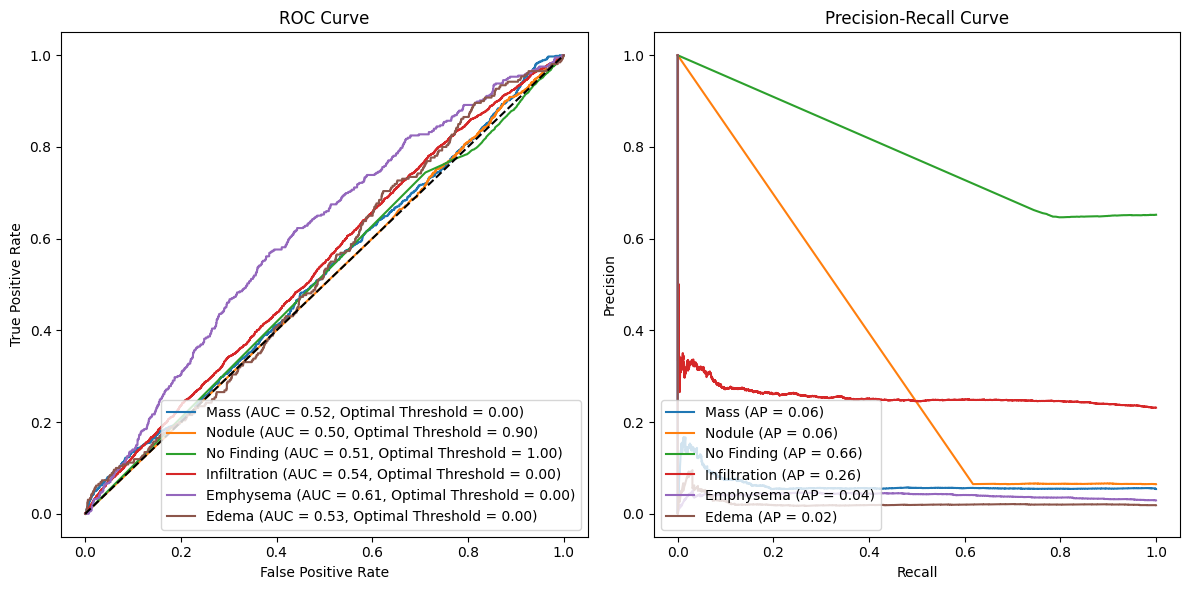

Best threshold for Mass: 0.004
Confusion Matrix for Mass (Threshold: 0.004):
[[11761  1262]
 [  644   100]]
Specificity for Mass: 0.9030945250710282
Best threshold for Nodule: 0.0941
Confusion Matrix for Nodule (Threshold: 0.0941):
[[    6 12870]
 [    0   891]]
Specificity for Nodule: 0.00046598322460391424
Best threshold for No Finding: 0.0001
Confusion Matrix for No Finding (Threshold: 0.0001):
[[   0 4789]
 [   0 8978]]
Specificity for No Finding: 0.0
Best threshold for Infiltration: 0.0001
Confusion Matrix for Infiltration (Threshold: 0.0001):
[[10579     0]
 [ 3188     0]]
Specificity for Infiltration: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Emphysema: 0.0001
Confusion Matrix for Emphysema (Threshold: 0.0001):
[[13361     0]
 [  406     0]]
Specificity for Emphysema: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Edema: 0.0001
Confusion Matrix for Edema (Threshold: 0.0001):
[[13507     0]
 [  260     0]]
Specificity for Edema: 1.0
          Label  Best Threshold  Precision    Recall  F1-Score  Accuracy  \
0          Mass          0.0040   0.073421  0.134409  0.094967  0.861553   
1        Nodule          0.0941   0.064748  1.000000  0.121622  0.065156   
2    No Finding          0.0001   0.652139  1.000000  0.789448  0.652139   
3  Infiltration          0.0001   0.000000  0.000000  0.000000  0.768432   
4     Emphysema          0.0001   0.000000  0.000000  0.000000  0.970509   
5         Edema          0.0001   0.000000  0.000000  0.000000  0.981114   

        MCC    AUC-PR  
0  0.028400  0.062513  
1  0.005493  0.064970  
2  0.000000  0.659266  
3  0.000000  0.256614  
4  0.000000  0.039767  
5  0.000000  0.023048  


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


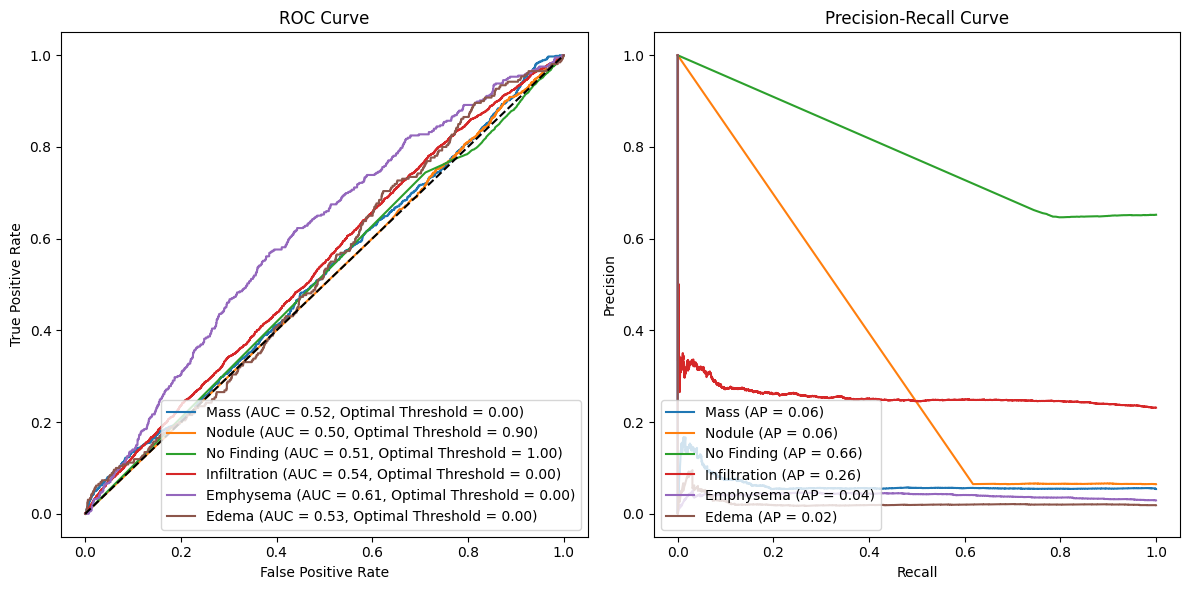

In [ ]:

# Function to train the model and save it
def train_and_save_model(model_name):
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=1e-5), loss=dice_loss, metrics=['accuracy'])

    # Define callbacks
    checkpoint = ModelCheckpoint(f'{model_name}.keras',
                                 monitor='val_accuracy',
                                 verbose=1,
                                 save_best_only=True,
                                 mode='max')
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    # Train the model
    history = model.fit(
        traingenerator,
        epochs=100,
        validation_data=valgenerator,
        callbacks=[checkpoint, early_stopping]
    )

    return history

# Train the model and save it
history = train_and_save_model('MobileNet+VGG16+Autoencoder_dice_loss')
###################################################################################################################

weighted_precision_list = []
weighted_recall_list = []
weighted_f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

predicted_vals = model.predict(testgenerator)
all_gt = np.array(testgenerator.labels)
all_pred_probs = predicted_vals

for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred_probs = all_pred_probs[:, i]

        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred, average="weighted")
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        pred = (pred_probs > best_thresh).astype(int)

        weighted_precision = precision_score(gt, pred, average="weighted")
        weighted_recall = recall_score(gt, pred, average="weighted")
        weighted_f1 = f1_score(gt, pred, average="weighted")
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        weighted_precision_list.append(weighted_precision)
        weighted_recall_list.append(weighted_recall)
        weighted_f1_list.append(weighted_f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass

metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Weighted Precision': weighted_precision_list,
    'Weighted Recall': weighted_recall_list,
    'Weighted F1-Score': weighted_f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

print("\nOverall Weighted Metrics:")
print(f"Mean Weighted Precision: {np.mean(weighted_precision_list):.4f}")
print(f"Mean Weighted Recall: {np.mean(weighted_recall_list):.4f}")
print(f"Mean Weighted F1-Score: {np.mean(weighted_f1_list):.4f}")
print(f"Mean Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Mean MCC: {np.mean(mcc_list):.4f}")
print(f"Mean AUC-PR: {np.mean(auc_pr_list):.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        youden_j = tpr - fpr
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()
##############################################################################################
# Initialize lists to store evaluation metrics for each label
precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

# Iterate through labels and calculate metrics
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred_probs = predicted_vals[:, i]

        # Find optimal threshold based on F1-score
        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        # Use the best threshold for evaluation
        pred = (pred_probs > best_thresh).astype(int)

        precision = precision_score(gt, pred)
        recall = recall_score(gt, pred)
        f1 = f1_score(gt, pred)
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        # Calculate Confusion Matrix
        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)
        # Calculate Specificity
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)
        print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass


# Store the metrics in a DataFrame for better presentation
metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-Score': f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

# Plot ROC and PR curves for each label in one plot
plt.figure(figsize=(12, 6))

# ROC curve
plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        # Calculate Youden's J for each threshold
        youden_j = tpr - fpr

        # Find the optimal threshold based on Youden's J
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# PR curve
plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

**tversky_loss**

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6582 - loss: 0.3617
Epoch 1: val_accuracy improved from -inf to 0.58741, saving model to MobileNet+VGG16+Autoencoder_tversky_loss.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1335s 1s/step - accuracy: 0.6582 - loss: 0.3617 - val_accuracy: 0.5874 - val_loss: 0.3750
Epoch 2/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6807 - loss: 0.2995
Epoch 2: val_accuracy improved from 0.58741 to 0.59583, saving model to MobileNet+VGG16+Autoencoder_tversky_loss.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1254s 1s/step - accuracy: 0.6807 - loss: 0.2995 - val_accuracy: 0.5958 - val_loss: 0.3691
Epoch 3/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6793 - loss: 0.2988
Epoch 3: val_accuracy improved from 0.59583 to 0.59613, saving model to MobileNet+VGG16+Autoencoder_tversky_loss.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1246s 1s/step - accuracy: 0.6793 - loss: 0.2988 - val_accuracy: 0.5961 - val_loss: 0.3660
Epoch 4/100
984/984 ━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Nodule: 0.0004
Confusion Matrix for Nodule (Threshold: 0.0004):
[[12876     0]
 [  889     2]]
Specificity for Nodule: 1.0
Best threshold for No Finding: 0.0001
Confusion Matrix for No Finding (Threshold: 0.0001):
[[   0 4789]
 [   0 8978]]
Specificity for No Finding: 0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Infiltration: 0.0994
Confusion Matrix for Infiltration (Threshold: 0.0994):
[[7228 3351]
 [1399 1789]]
Specificity for Infiltration: 0.6832403818886473
Best threshold for Emphysema: 0.0006000000000000001
Confusion Matrix for Emphysema (Threshold: 0.0006000000000000001):
[[13361     0]
 [  406     0]]
Specificity for Emphysema: 1.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Edema: 0.0563
Confusion Matrix for Edema (Threshold: 0.0563):
[[13507     0]
 [  260     0]]
Specificity for Edema: 1.0
          Label  Best Threshold  Weighted Precision  Weighted Recall  \
0          Mass          0.0198            0.894836         0.945958   
1        Nodule          0.0004            0.939596         0.935425   
2    No Finding          0.0001            0.425286         0.652139   
3  Infiltration          0.0994            0.724417         0.654972   
4     Emphysema          0.0006            0.941888         0.970509   
5         Edema          0.0563            0.962585         0.981114   

   Weighted F1-Score  Accuracy       MCC    AUC-PR  
0           0.919687  0.945958  0.000000  0.053966  
1           0.904360  0.935425  0.045822  0.061357  
2           0.514830  0.652139  0.000000  0.726354  
3           0.677874  0.654972  0.213149  0.381948  
4           0.955984  0.970509  0.000000  0.035971  
5           0.971761  0.981114  0.0000

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


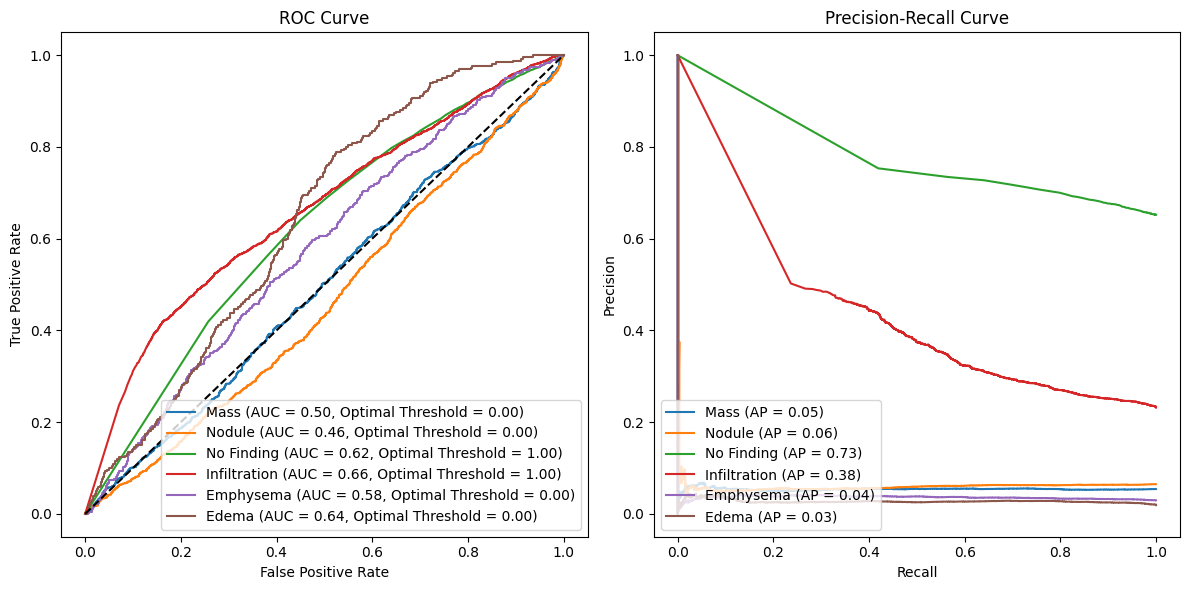

Best threshold for Mass: 0.0001
Confusion Matrix for Mass (Threshold: 0.0001):
[[12917   106]
 [  740     4]]
Specificity for Mass: 0.9918605544037472
Best threshold for Nodule: 0.0001
Confusion Matrix for Nodule (Threshold: 0.0001):
[[12851    25]
 [  888     3]]
Specificity for Nodule: 0.9980584032308171
Best threshold for No Finding: 0.0001
Confusion Matrix for No Finding (Threshold: 0.0001):
[[   0 4789]
 [   0 8978]]
Specificity for No Finding: 0.0
Best threshold for Infiltration: 0.08360000000000001
Confusion Matrix for Infiltration (Threshold: 0.08360000000000001):
[[7195 3384]
 [1387 1801]]
Specificity for Infiltration: 0.6801209944229133
Best threshold for Emphysema: 0.0001
Confusion Matrix for Emphysema (Threshold: 0.0001):
[[13321    40]
 [  406     0]]
Specificity for Emphysema: 0.9970062121098721
Best threshold for Edema: 0.0001
Confusion Matrix for Edema (Threshold: 0.0001):
[[13259   248]
 [  250    10]]
Specificity for Edema: 0.9816391500703339
          Label  Best Thr

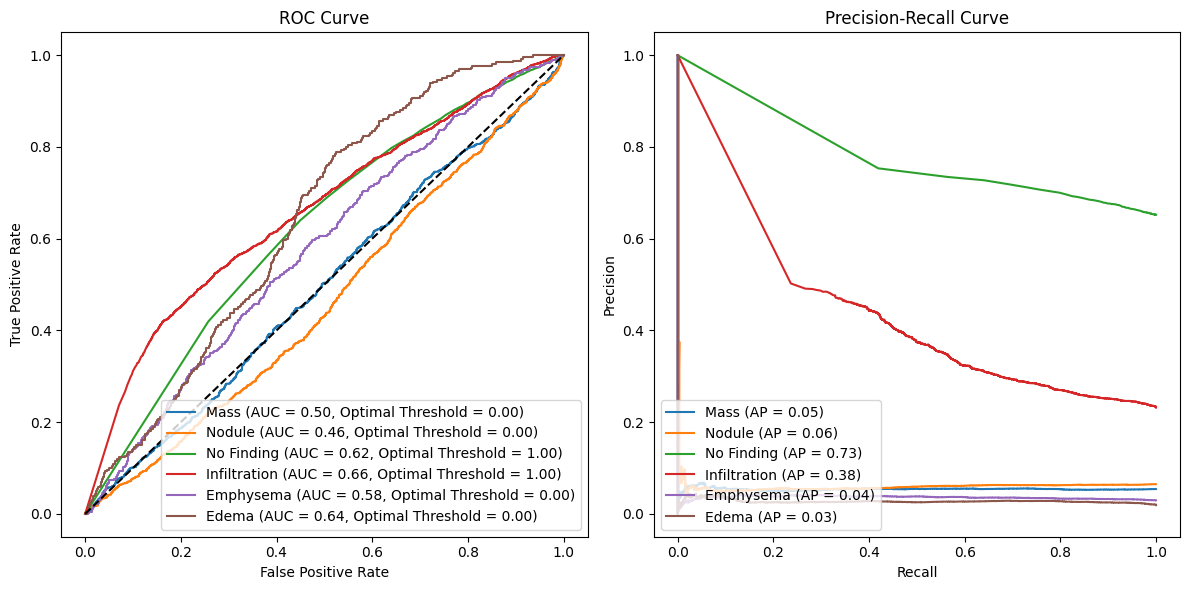

In [ ]:

# Function to train the model and save it
def train_and_save_model(model_name):
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=1e-5), loss=tversky_loss, metrics=['accuracy'])

    # Define callbacks
    checkpoint = ModelCheckpoint(f'{model_name}.keras',
                                 monitor='val_accuracy',
                                 verbose=1,
                                 save_best_only=True,
                                 mode='max')
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    # Train the model
    history = model.fit(
        traingenerator,
        epochs=100,
        validation_data=valgenerator,
        callbacks=[checkpoint, early_stopping]
    )

    return history

# Train the model and save it
history = train_and_save_model('MobileNet+VGG16+Autoencoder_tversky_loss')
###################################################################################################################

weighted_precision_list = []
weighted_recall_list = []
weighted_f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

predicted_vals = model.predict(testgenerator)
all_gt = np.array(testgenerator.labels)
all_pred_probs = predicted_vals

for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred_probs = all_pred_probs[:, i]

        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred, average="weighted")
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        pred = (pred_probs > best_thresh).astype(int)

        weighted_precision = precision_score(gt, pred, average="weighted")
        weighted_recall = recall_score(gt, pred, average="weighted")
        weighted_f1 = f1_score(gt, pred, average="weighted")
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        weighted_precision_list.append(weighted_precision)
        weighted_recall_list.append(weighted_recall)
        weighted_f1_list.append(weighted_f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass

metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Weighted Precision': weighted_precision_list,
    'Weighted Recall': weighted_recall_list,
    'Weighted F1-Score': weighted_f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

print("\nOverall Weighted Metrics:")
print(f"Mean Weighted Precision: {np.mean(weighted_precision_list):.4f}")
print(f"Mean Weighted Recall: {np.mean(weighted_recall_list):.4f}")
print(f"Mean Weighted F1-Score: {np.mean(weighted_f1_list):.4f}")
print(f"Mean Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Mean MCC: {np.mean(mcc_list):.4f}")
print(f"Mean AUC-PR: {np.mean(auc_pr_list):.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        youden_j = tpr - fpr
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()
##############################################################################################
# Initialize lists to store evaluation metrics for each label
precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

# Iterate through labels and calculate metrics
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred_probs = predicted_vals[:, i]

        # Find optimal threshold based on F1-score
        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        # Use the best threshold for evaluation
        pred = (pred_probs > best_thresh).astype(int)

        precision = precision_score(gt, pred)
        recall = recall_score(gt, pred)
        f1 = f1_score(gt, pred)
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        # Calculate Confusion Matrix
        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)
        # Calculate Specificity
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)
        print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass


# Store the metrics in a DataFrame for better presentation
metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-Score': f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

# Plot ROC and PR curves for each label in one plot
plt.figure(figsize=(12, 6))

# ROC curve
plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        # Calculate Youden's J for each threshold
        youden_j = tpr - fpr

        # Find the optimal threshold based on Youden's J
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# PR curve
plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

**asymmetric_focusing_cross_entropy**

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0546 - loss: 3.3640
Epoch 1: val_accuracy improved from -inf to 0.10798, saving model to MobileNet+VGG16+Autoencoder_asymmetric_focusing_cross_entropy.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1660s 2s/step - accuracy: 0.0546 - loss: 3.3634 - val_accuracy: 0.1080 - val_loss: 2.8069
Epoch 2/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0544 - loss: 2.5665
Epoch 2: val_accuracy improved from 0.10798 to 0.10813, saving model to MobileNet+VGG16+Autoencoder_asymmetric_focusing_cross_entropy.keras
984/984 ━━━━━━━━━━━━━━━━━━━━ 1620s 2s/step - accuracy: 0.0544 - loss: 2.5665 - val_accuracy: 0.1081 - val_loss: 2.7855
Epoch 3/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0573 - loss: 2.5732
Epoch 3: val_accuracy did not improve from 0.10813
984/984 ━━━━━━━━━━━━━━━━━━━━ 1612s 2s/step - accuracy: 0.0573 - loss: 2.5732 - val_accuracy: 0.1081 - val_loss: 2.7529
Epoch 4/100
984/984 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for No Finding: 0.0001
Confusion Matrix for No Finding (Threshold: 0.0001):
[[   0 4789]
 [   0 8978]]
Specificity for No Finding: 0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best threshold for Infiltration: 0.09970000000000001
Confusion Matrix for Infiltration (Threshold: 0.09970000000000001):
[[5869 4710]
 [1872 1316]]
Specificity for Infiltration: 0.5547783344361471
Best threshold for Emphysema: 0.0999
Confusion Matrix for Emphysema (Threshold: 0.0999):
[[5260 8101]
 [  59  347]]
Specificity for Emphysema: 0.39368310755182995
Best threshold for Edema: 0.0999
Confusion Matrix for Edema (Threshold: 0.0999):
[[10196  3311]
 [  183    77]]
Specificity for Edema: 0.7548678463019175
          Label  Best Threshold  Weighted Precision  Weighted Recall  \
0          Mass          0.0889            0.900042         0.944723   
1        Nodule          0.0001            0.004189         0.064720   
2    No Finding          0.0001            0.425286         0.652139   
3  Infiltration          0.0997            0.633174         0.521900   
4     Emphysema          0.0999            0.960955         0.407278   
5         Edema          0.0999            0.964245   

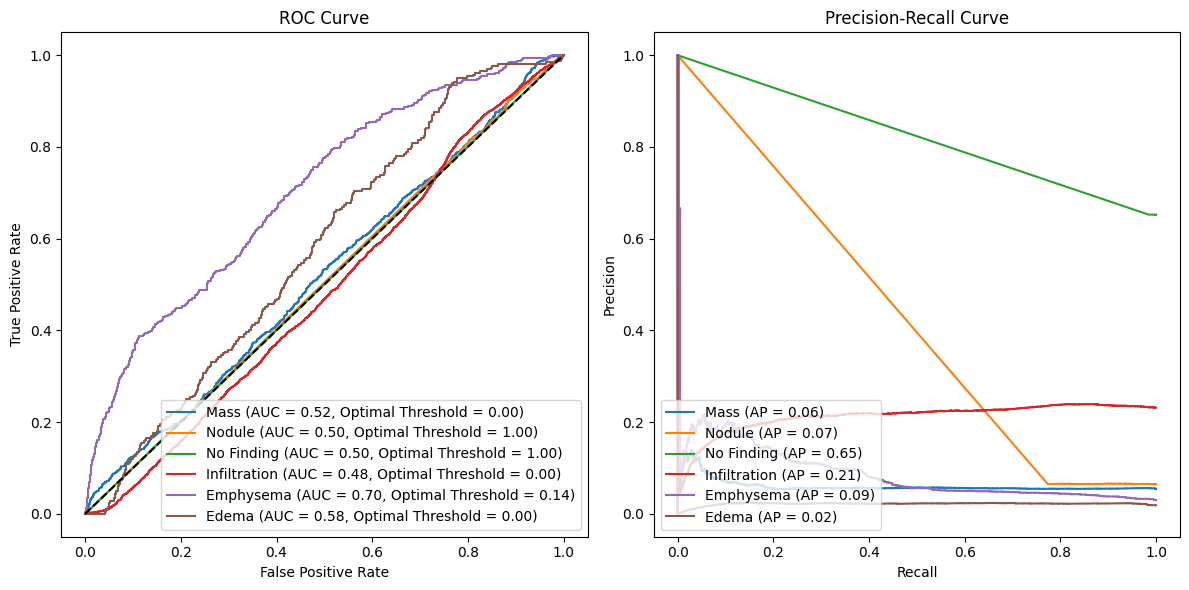

Best threshold for Mass: 0.006
Confusion Matrix for Mass (Threshold: 0.006):
[[11209  1814]
 [  620   124]]
Specificity for Mass: 0.8607079781924288
Best threshold for Nodule: 0.0001
Confusion Matrix for Nodule (Threshold: 0.0001):
[[    0 12876]
 [    0   891]]
Specificity for Nodule: 0.0
Best threshold for No Finding: 0.0001
Confusion Matrix for No Finding (Threshold: 0.0001):
[[   0 4789]
 [   0 8978]]
Specificity for No Finding: 0.0
Best threshold for Infiltration: 0.0007000000000000001
Confusion Matrix for Infiltration (Threshold: 0.0007000000000000001):
[[ 627 9952]
 [ 140 3048]]
Specificity for Infiltration: 0.05926836184894602
Best threshold for Emphysema: 0.09930000000000001
Confusion Matrix for Emphysema (Threshold: 0.09930000000000001):
[[5240 8121]
 [  58  348]]
Specificity for Emphysema: 0.392186213606766
Best threshold for Edema: 0.008
Confusion Matrix for Edema (Threshold: 0.008):
[[6454 7053]
 [  89  171]]
Specificity for Edema: 0.47782631228252015
          Label  Best

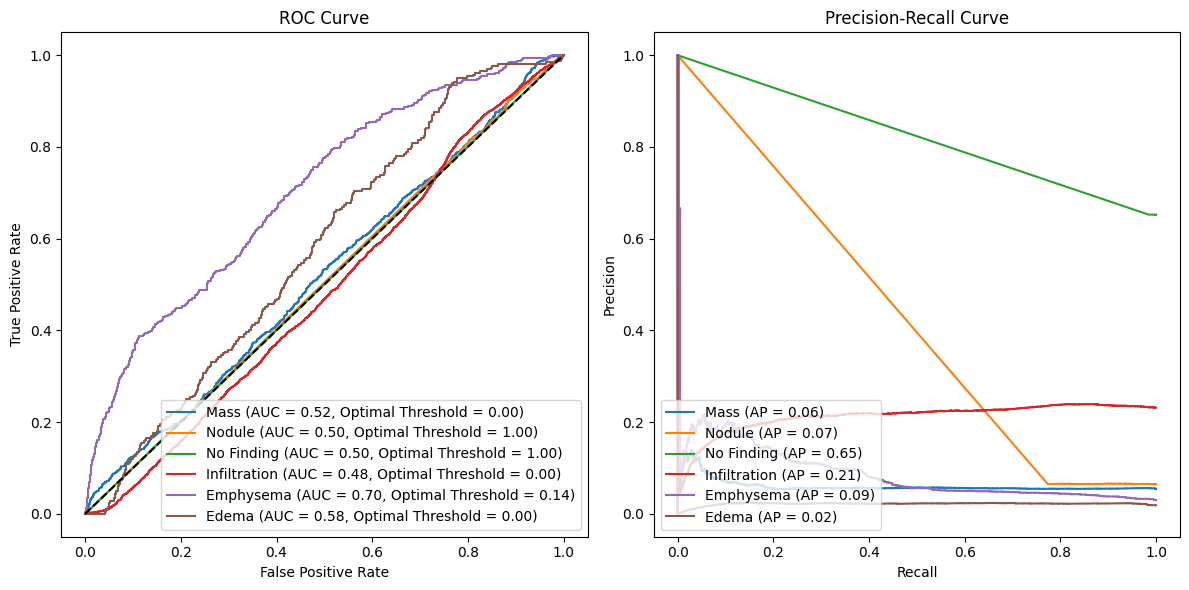

In [ ]:

# Function to train the model and save it
def train_and_save_model(model_name):
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=1e-5), loss=asymmetric_focusing_cross_entropy, metrics=['accuracy'])

    # Define callbacks
    checkpoint = ModelCheckpoint(f'{model_name}.keras',
                                 monitor='val_accuracy',
                                 verbose=1,
                                 save_best_only=True,
                                 mode='max')
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    # Train the model
    history = model.fit(
        traingenerator,
        epochs=100,
        validation_data=valgenerator,
        callbacks=[checkpoint, early_stopping]
    )

    return history

# Train the model and save it
history = train_and_save_model('MobileNet+VGG16+Autoencoder_asymmetric_focusing_cross_entropy')
###################################################################################################################

weighted_precision_list = []
weighted_recall_list = []
weighted_f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

predicted_vals = model.predict(testgenerator)
all_gt = np.array(testgenerator.labels)
all_pred_probs = predicted_vals

for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred_probs = all_pred_probs[:, i]

        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred, average="weighted")
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        pred = (pred_probs > best_thresh).astype(int)

        weighted_precision = precision_score(gt, pred, average="weighted")
        weighted_recall = recall_score(gt, pred, average="weighted")
        weighted_f1 = f1_score(gt, pred, average="weighted")
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        weighted_precision_list.append(weighted_precision)
        weighted_recall_list.append(weighted_recall)
        weighted_f1_list.append(weighted_f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass

metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Weighted Precision': weighted_precision_list,
    'Weighted Recall': weighted_recall_list,
    'Weighted F1-Score': weighted_f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

print("\nOverall Weighted Metrics:")
print(f"Mean Weighted Precision: {np.mean(weighted_precision_list):.4f}")
print(f"Mean Weighted Recall: {np.mean(weighted_recall_list):.4f}")
print(f"Mean Weighted F1-Score: {np.mean(weighted_f1_list):.4f}")
print(f"Mean Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Mean MCC: {np.mean(mcc_list):.4f}")
print(f"Mean AUC-PR: {np.mean(auc_pr_list):.4f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        youden_j = tpr - fpr
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = all_gt[:, i]
        pred = all_pred_probs[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()
##############################################################################################
# Initialize lists to store evaluation metrics for each label
precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
mcc_list = []
auc_pr_list = []
best_thresholds = []

# Iterate through labels and calculate metrics
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred_probs = predicted_vals[:, i]

        # Find optimal threshold based on F1-score
        best_f1 = -1
        best_thresh = 0
        for thresh in np.arange(0.0001, 0.0999999, 0.0001):
            pred = (pred_probs > thresh).astype(int)
            f1 = f1_score(gt, pred)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds.append(best_thresh)
        print(f"Best threshold for {labels[i]}: {best_thresh}")

        # Use the best threshold for evaluation
        pred = (pred_probs > best_thresh).astype(int)

        precision = precision_score(gt, pred)
        recall = recall_score(gt, pred)
        f1 = f1_score(gt, pred)
        accuracy = accuracy_score(gt, pred)
        mcc = matthews_corrcoef(gt, pred)
        auc_pr = average_precision_score(gt, pred_probs)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        accuracy_list.append(accuracy)
        mcc_list.append(mcc)
        auc_pr_list.append(auc_pr)

        # Calculate Confusion Matrix
        cm = confusion_matrix(gt, pred)
        print(f"Confusion Matrix for {labels[i]} (Threshold: {best_thresh}):")
        print(cm)
        # Calculate Specificity
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)
        print(f"Specificity for {labels[i]}: {specificity}")

    except ValueError:
        pass


# Store the metrics in a DataFrame for better presentation
metrics_df = pd.DataFrame({
    'Label': labels,
    'Best Threshold': best_thresholds,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-Score': f1_list,
    'Accuracy': accuracy_list,
    'MCC': mcc_list,
    'AUC-PR': auc_pr_list
})

print(metrics_df)

# Plot ROC and PR curves for each label in one plot
plt.figure(figsize=(12, 6))

# ROC curve
plt.subplot(1, 2, 1)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        fpr, tpr, thresholds = roc_curve(gt, pred)

        # Calculate Youden's J for each threshold
        youden_j = tpr - fpr

        # Find the optimal threshold based on Youden's J
        optimal_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[optimal_idx]

        roc_auc = roc_auc_score(gt, pred)
        plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f}, Optimal Threshold = {optimal_threshold:.2f})")
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# PR curve
plt.subplot(1, 2, 2)
for i in range(len(labels)):
    try:
        gt = np.array(testgenerator.labels[:, i])
        pred = predicted_vals[:, i]
        precision, recall, _ = precision_recall_curve(gt, pred)
        average_precision = average_precision_score(gt, pred)
        plt.plot(recall, precision, label=f"{labels[i]} (AP = {average_precision:.2f})")
    except ValueError:
        pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()